In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('laptops.csv')

In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [4]:
df = df[['ram', 'storage', 'screen', 'final_price']].copy()

In [5]:
import seaborn as sns

<Axes: xlabel='final_price', ylabel='Count'>

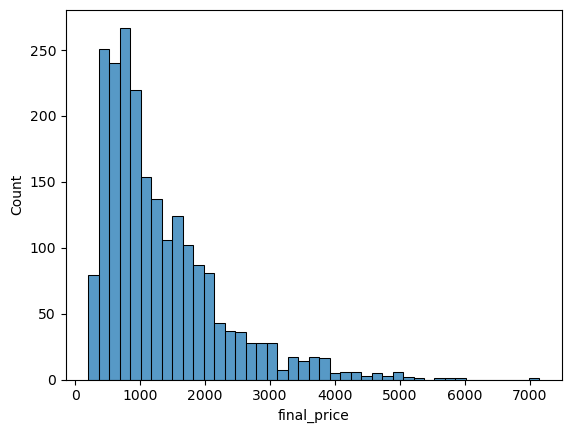

In [6]:
sns.histplot(df.final_price)

In [7]:
# Q1: whick columns have missing values

missing_series = df.isnull().sum()

print(missing_series[missing_series != 0].index)

Index(['screen'], dtype='object')


In [8]:
# Q2: median of ram

ram_median = df.ram.median()

print(f'ram median is: {ram_median}')

ram median is: 16.0


Prepare and split the data

In [9]:
import numpy as np

np.random.seed(42)

In [10]:
n = len(df)

idx = np.arange(n)

np.random.shuffle(idx)

n_val = int(n * 0.2)
n_test  =int(n * 0.2)
n_train = n - n_val - n_test

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
df_test = df_shuffled.iloc[n_train + n_val:].copy()

In [11]:
df_train.columns

Index(['ram', 'storage', 'screen', 'final_price'], dtype='object')

In [12]:
# Q3:

# filling with zeros

df_train_0fill = df_train.fillna(0)
df_val_0fill = df_val.fillna(0)
df_test_0fill = df_test.fillna(0)

y_train = df_train_0fill.final_price.values
y_val = df_val_0fill.final_price.values
y_test = df_test_0fill.final_price.values

X_train = df_train_0fill.drop('final_price', axis = 1).values
X_val = df_val_0fill.drop('final_price', axis = 1).values
X_test = df_test_0fill.drop('final_price', axis = 1).values

from utils import linear_regression

w0, w1 = linear_regression(X_train, y_train)

y_pred = X_val.dot(w1) + w0

from utils import rmse

rmse_value = round(rmse(y_pred, y_val), 2)

print(f'rmse value for filling with zeros: {rmse_value}')

rmse value for filling with zeros: 597.36


In [13]:
# Q3:

# filling with zeros

training_mean = df_train.mean()

df_train_meanfill = df_train.fillna(training_mean)
df_val_meanfill = df_val.fillna(training_mean)
df_test_meanfill = df_test.fillna(training_mean)

y_train = df_train_meanfill.final_price.values
y_val = df_val_meanfill.final_price.values
y_test = df_test_meanfill.final_price.values

X_train = df_train_meanfill.drop('final_price', axis = 1).values
X_val = df_val_meanfill.drop('final_price', axis = 1).values
X_test = df_test_meanfill.drop('final_price', axis = 1).values

from utils import linear_regression

w0, w1 = linear_regression(X_train, y_train)

y_pred = X_val.dot(w1) + w0

from utils import rmse

rmse_value = round(rmse(y_pred, y_val), 2)

print(f'rmse value for filling with the training mean: {rmse_value}')

rmse value for filling with the training mean: 600.27


In [14]:
# Q4: linear regression with regularization

# filling with zeros

df_train_0fill = df_train.fillna(0)
df_val_0fill = df_val.fillna(0)
df_test_0fill = df_test.fillna(0)

y_train = df_train_0fill.final_price.values
y_val = df_val_0fill.final_price.values
y_test = df_test_0fill.final_price.values

X_train = df_train_0fill.drop('final_price', axis = 1).values
X_val = df_val_0fill.drop('final_price', axis = 1).values
X_test = df_test_0fill.drop('final_price', axis = 1).values

from utils import linear_regression_reg
from utils import rmse

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w1 = linear_regression_reg(X_train, y_train, r)
    y_pred = X_val.dot(w1) + w0
    rmse_value = round(rmse(y_pred, y_val), 2)
    print(f'rmse value for regularization with coeff {r} filling with zeros: {rmse_value}')

rmse value for regularization with coeff 0 filling with zeros: 597.36
rmse value for regularization with coeff 0.01 filling with zeros: 597.36
rmse value for regularization with coeff 0.1 filling with zeros: 597.35
rmse value for regularization with coeff 1 filling with zeros: 597.21
rmse value for regularization with coeff 5 filling with zeros: 597.01
rmse value for regularization with coeff 10 filling with zeros: 597.06
rmse value for regularization with coeff 100 filling with zeros: 597.9


In [15]:
# Q5

scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed=seed)
    n = len(df)

    idx = np.arange(n)

    np.random.shuffle(idx)

    n_val = int(n * 0.2)
    n_test  =int(n * 0.2)
    n_train = n - n_val - n_test

    df_shuffled = df.iloc[idx]

    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
    df_test = df_shuffled.iloc[n_train + n_val:].copy()

    df_train_0fill = df_train.fillna(0)
    df_val_0fill = df_val.fillna(0)
    df_test_0fill = df_test.fillna(0)

    y_train = df_train_0fill.final_price.values
    y_val = df_val_0fill.final_price.values
    y_test = df_test_0fill.final_price.values

    X_train = df_train_0fill.drop('final_price', axis = 1).values
    X_val = df_val_0fill.drop('final_price', axis = 1).values
    X_test = df_test_0fill.drop('final_price', axis = 1).values

    w0, w1 = linear_regression(X_train, y_train)

    y_pred = X_val.dot(w1) + w0

    rmse_value = round(rmse(y_pred, y_val), 2)

    scores.append(rmse_value)

    print(f'rmse value for seed {seed} and filling with zeros: {rmse_value}')


rmse_std = round(np.std(scores), 3)

print(f'the rmse std is {rmse_std}')

rmse value for seed 0 and filling with zeros: 565.45
rmse value for seed 1 and filling with zeros: 636.8
rmse value for seed 2 and filling with zeros: 588.96
rmse value for seed 3 and filling with zeros: 597.81
rmse value for seed 4 and filling with zeros: 571.96
rmse value for seed 5 and filling with zeros: 573.24
rmse value for seed 6 and filling with zeros: 647.34
rmse value for seed 7 and filling with zeros: 550.44
rmse value for seed 8 and filling with zeros: 587.33
rmse value for seed 9 and filling with zeros: 576.1
the rmse std is 29.176


In [16]:
np.random.seed(9)
n = len(df)

idx = np.arange(n)

np.random.shuffle(idx)

n_val = int(n * 0.2)
n_test  =int(n * 0.2)
n_train = n - n_val - n_test

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train + n_val:].copy()

df_train_0fill = df_train.fillna(0)
df_test_0fill = df_test.fillna(0)

y_train = df_train_0fill.final_price.values
y_test = df_test_0fill.final_price.values

X_train = df_train_0fill.drop('final_price', axis = 1).values
X_test = df_test_0fill.drop('final_price', axis = 1).values

w0, w1 = linear_regression_reg(X_train, y_train, r = 0.001)
y_pred = X_test.dot(w1) + w0
rmse_value = round(rmse(y_pred, y_test), 2)
print(f'rmse value for regularization with coeff {r} filling with zeros: {rmse_value}')

rmse value for regularization with coeff 100 filling with zeros: 608.61
